# MCD19A2 Station-Level AOD — Exploratory Data Analysis

EDA for the station-extracted MCD19A2 MODIS AOD dataset.  
Data source: `/home/slow_data/Air_Quality/MODIS_MCD19A2/stations_aod_v3/`  
Extraction script: `extract_station_mcd.py`

**Variables per station:**
- `Optical_Depth_047 / 055` — AOD at 0.47 µm and 0.55 µm  
- `AOD_Uncertainty`, `AngstromExp_470-780`, `Column_WV`, `FineModeFraction`, `Injection_Height`  
- `AOD_QA` — 16-bit quality flag  
- Geometric angles: `cosSZA`, `cosVZA`, `RelAZ`, `Scattering_Angle`, `Glint_Angle`  
- `*_fill_ring` — Chebyshev fill radius used (NaN/0 = exact pixel hit)

## 1. Setup

In [1]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
%matplotlib inline

STATION_DIR = '/home/slow_data/Air_Quality/MODIS_MCD19A2/stations_aod_v3'

AOD_COLS   = ['Optical_Depth_047', 'Optical_Depth_055']
AUX_COLS   = ['AOD_Uncertainty', 'Column_WV', 'AngstromExp_470-780',
              'FineModeFraction', 'Injection_Height']
ANGLE_COLS = ['cosSZA', 'cosVZA', 'RelAZ', 'Scattering_Angle', 'Glint_Angle']

MONTH_LABELS = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']
print('Setup complete.')

Setup complete.


## 2. Load All Station CSVs

In [2]:
csv_files = sorted(glob.glob(os.path.join(STATION_DIR, '*.csv')))
print(f'Found {len(csv_files)} station CSV files')

dfs = []
for f in csv_files:
    try:
        dfs.append(pd.read_csv(f, parse_dates=['timestamp']))
    except Exception as e:
        print(f'  [!] {os.path.basename(f)}: {e}')

data = pd.concat(dfs, ignore_index=True)
data['date']  = data['timestamp'].dt.normalize()
data['year']  = data['timestamp'].dt.year
data['month'] = data['timestamp'].dt.month
data['hour']  = data['timestamp'].dt.hour
data['stationId'] = data['stationId'].astype(str)

print(f'\nTotal records : {len(data):,}')
print(f'Stations      : {data["stationId"].nunique()}')
print(f'Date range    : {data["date"].min().date()} -> {data["date"].max().date()}')
data.head(3)

Found 123 station CSV files

Total records : 75,876
Stations      : 123
Date range    : 2022-09-01 -> 2026-03-10


,stationId,stationName,timestamp,Timestamp_MODIS_str,Optical_Depth_047,Optical_Depth_047_fill_ring,Optical_Depth_055,Optical_Depth_055_fill_ring,AOD_Uncertainty,AOD_Uncertainty_fill_ring,...,RelAZ,RelAZ_fill_ring,Scattering_Angle,Scattering_Angle_fill_ring,Glint_Angle,Glint_Angle_fill_ring,date,year,month,hour
0,31388839920718814259329251882,"Bình Dương: số 593 Đại lộ Bình Dương, P. Hiệp ...",2022-09-01 13:50:00,20220901_1350,0.255,NaN,0.184,NaN,0.0310,NaN,...,175.11,NaN,165.81,NaN,70.31,NaN,2022-09-01,2022,9,13
1,31388839920718814259329251882,"Bình Dương: số 593 Đại lộ Bình Dương, P. Hiệp ...",2022-09-02 10:05:00,20220902_1005,0.350,1.0,0.253,1.0,0.0589,NaN,...,176.61,NaN,177.01,NaN,50.88,NaN,2022-09-02,2022,9,10
2,31388839920718814259329251882,"Bình Dương: số 593 Đại lộ Bình Dương, P. Hiệp ...",2022-09-03 13:30:00,20220903_1330,0.274,1.0,0.197,1.0,0.0734,NaN,...,178.66,NaN,172.67,NaN,43.46,NaN,2022-09-03,2022,9,13


## 3. Dataset Overview

In [3]:
station_counts = (
    data.groupby('stationName')
        .agg(n_records=('timestamp', 'count'),
             date_min=('date', 'min'),
             date_max=('date', 'max'))
        .sort_values('n_records', ascending=False)
)
print('=== Records per station ===')
print(station_counts.to_string())
print(f'\nMedian records/station : {station_counts["n_records"].median():.0f}')
print(f'Min / Max              : {station_counts["n_records"].min()} / {station_counts["n_records"].max()}')

=== Records per station ===
                                                                                                         n_records   date_min   date_max
stationName                                                                                                                             
Ninh Thuận: Công viên (bến xe cũ) - Đ. Thống Nhất - P. Thanh Sơn - TP Phan Rang (KK)                          1139 2022-09-01 2026-03-10
Gia lai: Chư Sê (KK)                                                                                          1026 2022-09-01 2026-03-10
Đà Nẵng: 41 đường Lê Duẩn (KK)                                                                                 933 2022-09-01 2026-03-08
Gia Lai: KCN Trà Đa - Tp Pleiku (KK)                                                                           924 2022-09-01 2026-03-09
Quảng Ngãi: UBND P. Nguyễn Nghiêm - TP Quảng Ngãi (KK)                                                         919 2022-09-01 2026-03-10
Trà Vinh: xã 

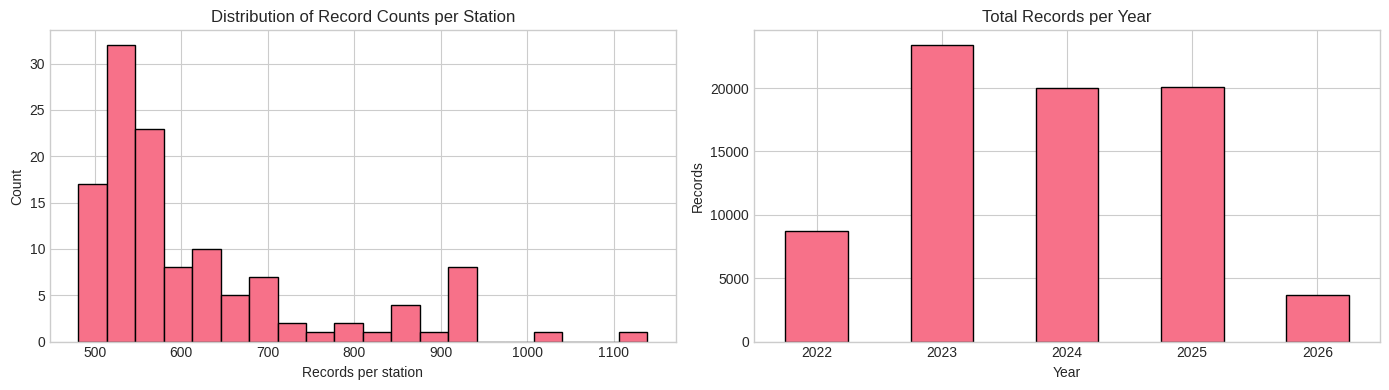

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

station_counts['n_records'].hist(bins=20, ax=axes[0], edgecolor='k')
axes[0].set_xlabel('Records per station')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Record Counts per Station')

data.groupby('year').size().plot(kind='bar', ax=axes[1], edgecolor='k')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Records')
axes[1].set_title('Total Records per Year')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 4. Missing Data Analysis

                     missing_n  missing_pct  valid_n
Injection_Height         73135        96.39     2741
AngstromExp_470-780      70951        93.51     4925
Optical_Depth_047            0         0.00    75876
AOD_Uncertainty              0         0.00    75876
Optical_Depth_055            0         0.00    75876
Column_WV                    0         0.00    75876
FineModeFraction             0         0.00    75876


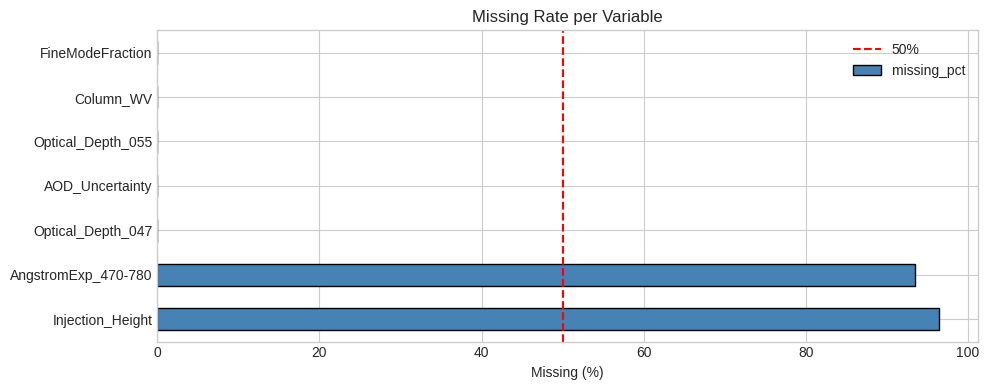

In [5]:
value_cols = AOD_COLS + AUX_COLS
missing = pd.DataFrame({
    'missing_n'  : data[value_cols].isna().sum(),
    'missing_pct': data[value_cols].isna().mean() * 100,
    'valid_n'    : data[value_cols].notna().sum(),
}).sort_values('missing_pct', ascending=False)
print(missing.round(2).to_string())

fig, ax = plt.subplots(figsize=(10, 4))
missing['missing_pct'].plot(kind='barh', ax=ax, color='steelblue', edgecolor='k')
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Rate per Variable')
ax.axvline(50, color='red', linestyle='--', lw=1.5, label='50%')
ax.legend()
plt.tight_layout()
plt.show()

## 5. AOD Distributions

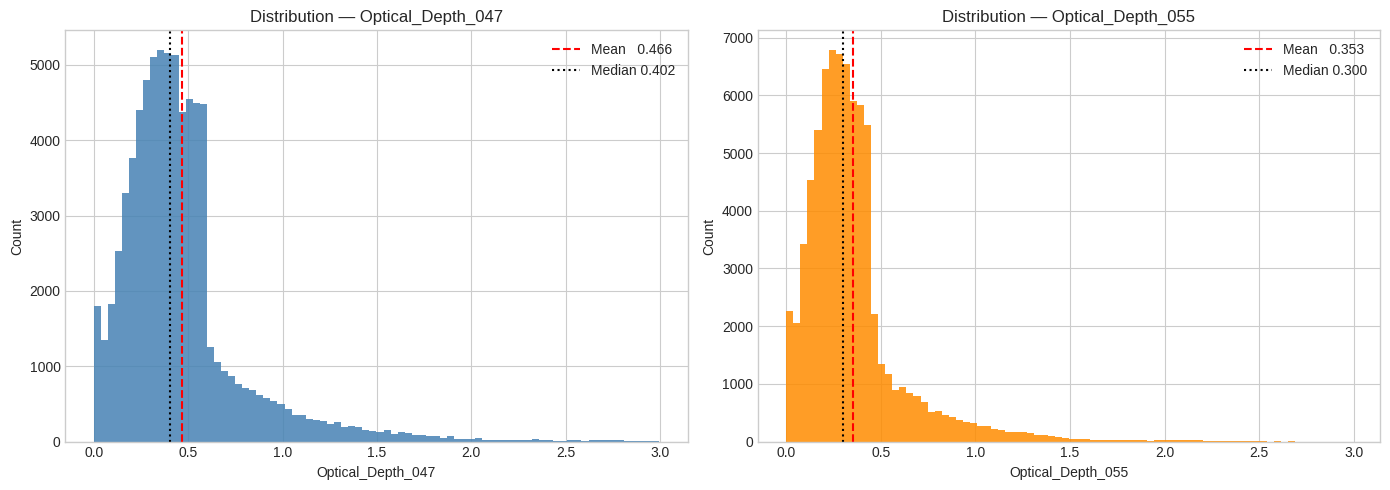


=== AOD Summary Statistics ===
       Optical_Depth_047  Optical_Depth_055
count         75876.0000         75876.0000
mean              0.4672             0.3536
std               0.3492             0.2719
min               0.0000             0.0000
25%               0.2623             0.1945
50%               0.4020             0.3000
75%               0.5540             0.4190
max               4.3840             3.4060
Optical_Depth_047: AOD > 1.0  ->  6.93%  (5257 records)
Optical_Depth_055: AOD > 1.0  ->  3.61%  (2742 records)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, color in zip(axes, AOD_COLS, ['steelblue', 'darkorange']):
    vals = data[col].dropna()
    vals = vals[(vals >= 0) & (vals <= 3)]
    ax.hist(vals, bins=80, color=color, edgecolor='none', alpha=0.85)
    ax.axvline(vals.mean(),   color='red',   lw=1.5, linestyle='--', label=f'Mean   {vals.mean():.3f}')
    ax.axvline(vals.median(), color='black', lw=1.5, linestyle=':',  label=f'Median {vals.median():.3f}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.set_title(f'Distribution — {col}')
    ax.legend()

plt.tight_layout()
plt.show()

print('\n=== AOD Summary Statistics ===')
print(data[AOD_COLS].describe().round(4).to_string())

for c in AOD_COLS:
    v = data[c].dropna()
    print(f'{c}: AOD > 1.0  ->  {(v > 1.0).mean()*100:.2f}%  ({(v > 1.0).sum()} records)')

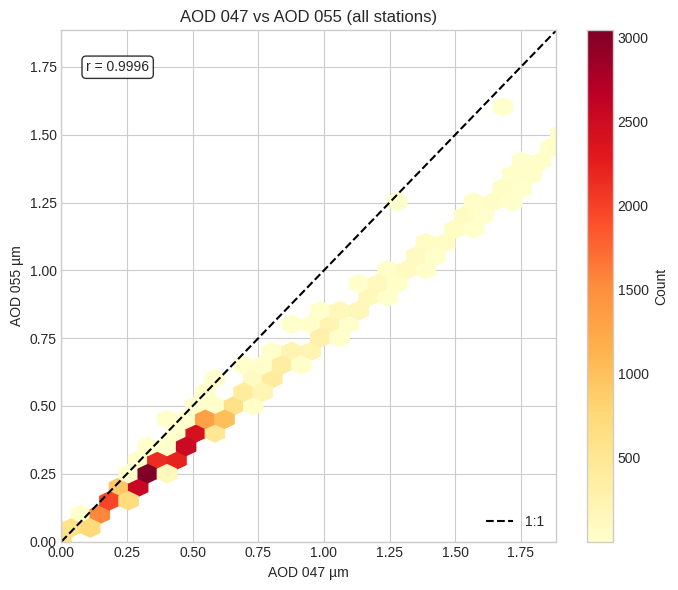

In [7]:
# AOD 047 vs 055
mask = data['Optical_Depth_047'].notna() & data['Optical_Depth_055'].notna()
sample = data[mask].sample(min(30_000, mask.sum()), random_state=42)

fig, ax = plt.subplots(figsize=(7, 6))
h = ax.hexbin(sample['Optical_Depth_047'], sample['Optical_Depth_055'],
              gridsize=60, cmap='YlOrRd', mincnt=1)
lim = max(sample['Optical_Depth_047'].quantile(0.99),
          sample['Optical_Depth_055'].quantile(0.99)) + 0.05
ax.plot([0, lim], [0, lim], 'k--', lw=1.5, label='1:1')
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.set_xlabel('AOD 047 µm')
ax.set_ylabel('AOD 055 µm')
ax.set_title('AOD 047 vs AOD 055 (all stations)')
r = sample['Optical_Depth_047'].corr(sample['Optical_Depth_055'])
ax.text(0.05, 0.92, f'r = {r:.4f}', transform=ax.transAxes,
        bbox=dict(boxstyle='round', fc='white', alpha=0.8))
ax.legend()
plt.colorbar(h, ax=ax, label='Count')
plt.tight_layout()
plt.show()

## 6. Spatial Fill Ring Analysis

`*_fill_ring` = NaN or 0 means the exact 1 km pixel was valid.  
Values 1–5 show how far out the Chebyshev neighbour search expanded.

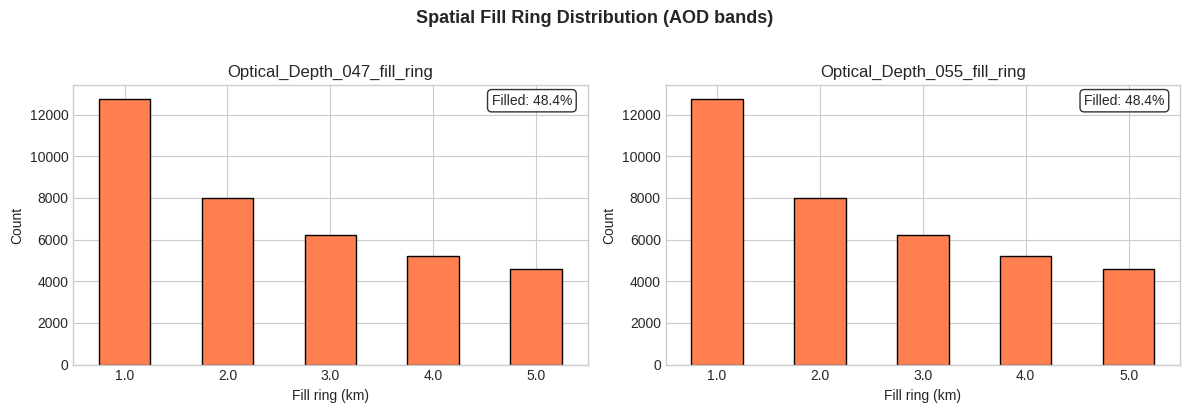

In [8]:
fill_cols = [f'{c}_fill_ring' for c in AOD_COLS if f'{c}_fill_ring' in data.columns]

fig, axes = plt.subplots(1, len(fill_cols), figsize=(6 * len(fill_cols), 4))
if len(fill_cols) == 1:
    axes = [axes]

for ax, fc in zip(axes, fill_cols):
    total = len(data)
    ring_vals = data[fc].dropna()
    ring_vals = ring_vals[ring_vals > 0]
    ring_counts = ring_vals.value_counts().sort_index()
    ring_counts.plot(kind='bar', ax=ax, edgecolor='k', color='coral')
    ax.set_xlabel('Fill ring (km)')
    ax.set_ylabel('Count')
    ax.set_title(fc)
    ax.tick_params(axis='x', rotation=0)
    pct = len(ring_vals) / total * 100
    ax.text(0.97, 0.97, f'Filled: {pct:.1f}%', transform=ax.transAxes,
            ha='right', va='top', bbox=dict(boxstyle='round', fc='white', alpha=0.8))

plt.suptitle('Spatial Fill Ring Distribution (AOD bands)', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. AOD Quality Flag (AOD_QA) Decoding

MCD19A2 `AOD_QA` is a 16-bit packed integer (MAIAC V061 ATBD):

| Bits | Field      | Values                                      |
|------|------------|---------------------------------------------|
| 0–2  | CloudAdj   | 0 = clear                                   |
| 3–5  | AOD Level  | 0 = best, 1 = good, 2 = marginal, 3 = cloud, 5 = no retrieval |
| 6    | Glint      | 1 = sun glint                               |
| 7    | Snow       | 1 = snow/ice                                |

In [9]:
qa_raw = data['AOD_QA'].dropna().astype(int)

cloud_adj  = qa_raw.apply(lambda x: (x >> 0) & 0b111)
aod_level  = qa_raw.apply(lambda x: (x >> 3) & 0b111)
glint_flag = qa_raw.apply(lambda x: (x >> 6) & 0b1)
snow_flag  = qa_raw.apply(lambda x: (x >> 7) & 0b1)

qa_df = pd.DataFrame({
    'cloud_adj' : cloud_adj.values,
    'aod_level' : aod_level.values,
    'glint'     : glint_flag.values,
    'snow'      : snow_flag.values,
}, index=qa_raw.index)

print('=== AOD Quality Level (bits 3-5) ===')
level_counts = qa_df['aod_level'].value_counts().sort_index()
level_pct    = (level_counts / len(qa_df) * 100).round(2)
print(pd.concat([level_counts.rename('count'), level_pct.rename('pct%')], axis=1).to_string())

print('\n=== Glint flag ===')
print(qa_df['glint'].value_counts().to_string())
print('\n=== Snow flag ===')
print(qa_df['snow'].value_counts().to_string())

=== AOD Quality Level (bits 3-5) ===
           count   pct%
aod_level              
0          67545  89.02
4           8331  10.98

=== Glint flag ===
glint
0    68778
1     7098

=== Snow flag ===
snow
0    75876


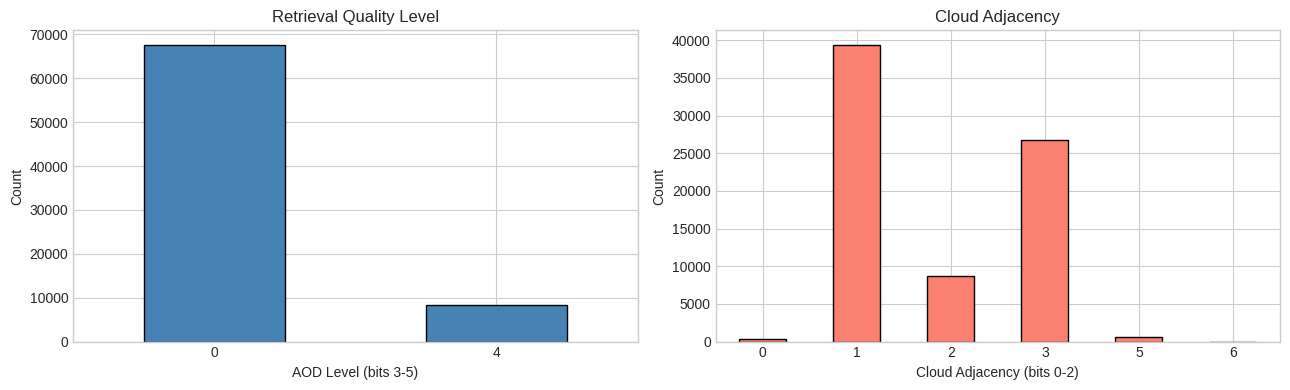

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

level_counts.plot(kind='bar', ax=axes[0], edgecolor='k', color='steelblue')
axes[0].set_xlabel('AOD Level (bits 3-5)')
axes[0].set_ylabel('Count')
axes[0].set_title('Retrieval Quality Level')
axes[0].tick_params(axis='x', rotation=0)

qa_df['cloud_adj'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], edgecolor='k', color='salmon')
axes[1].set_xlabel('Cloud Adjacency (bits 0-2)')
axes[1].set_ylabel('Count')
axes[1].set_title('Cloud Adjacency')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

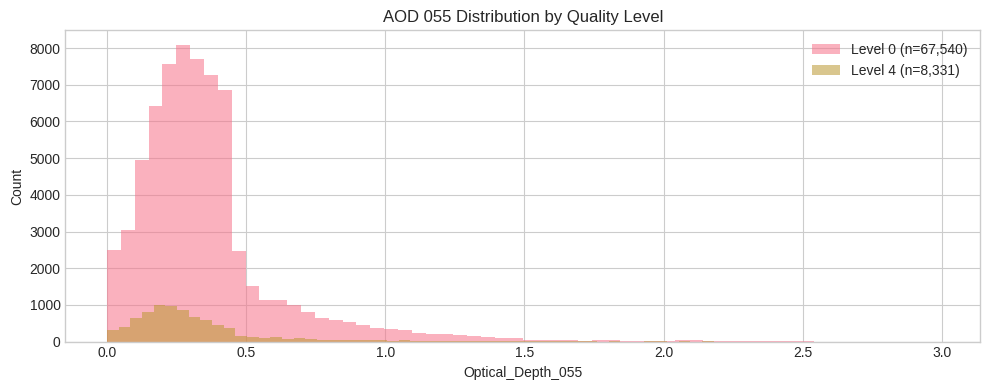

In [11]:
# AOD 055 by quality level
data_qa = data.copy()
data_qa['aod_level'] = qa_df['aod_level'].reindex(data_qa.index)

fig, ax = plt.subplots(figsize=(10, 4))
for level in sorted(data_qa['aod_level'].dropna().unique()):
    v = data_qa.loc[data_qa['aod_level'] == level, 'Optical_Depth_055'].dropna()
    v = v[(v >= 0) & (v <= 3)]
    if len(v) > 0:
        ax.hist(v, bins=60, alpha=0.55, label=f'Level {int(level)} (n={len(v):,})')
ax.set_xlabel('Optical_Depth_055')
ax.set_ylabel('Count')
ax.set_title('AOD 055 Distribution by Quality Level')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Temporal Analysis

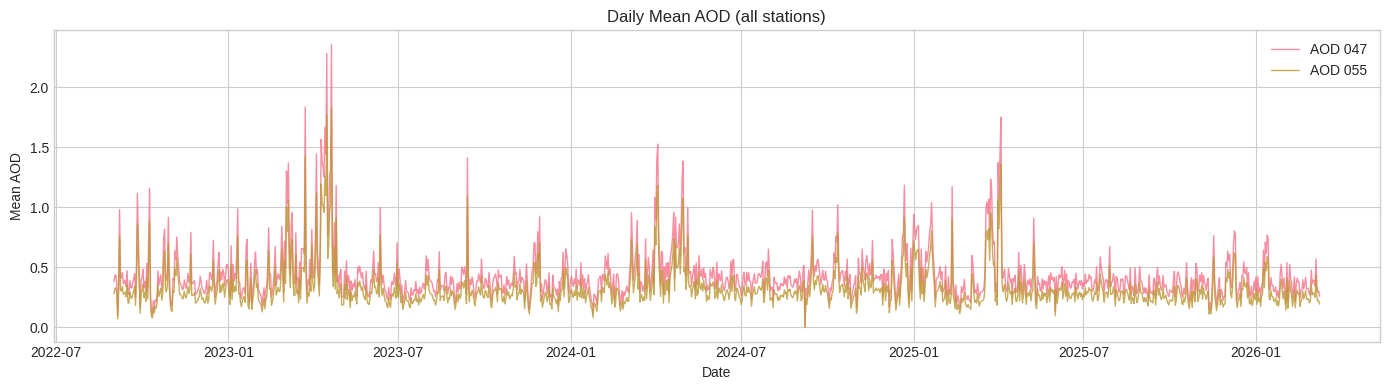

In [12]:
# Daily mean AOD
daily = data.groupby('date')[AOD_COLS].mean().dropna(how='all')

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily.index, daily['Optical_Depth_047'], label='AOD 047', lw=1.0, alpha=0.8)
ax.plot(daily.index, daily['Optical_Depth_055'], label='AOD 055', lw=1.0, alpha=0.8)
ax.set_xlabel('Date')
ax.set_ylabel('Mean AOD')
ax.set_title('Daily Mean AOD (all stations)')
ax.legend()
plt.tight_layout()
plt.show()

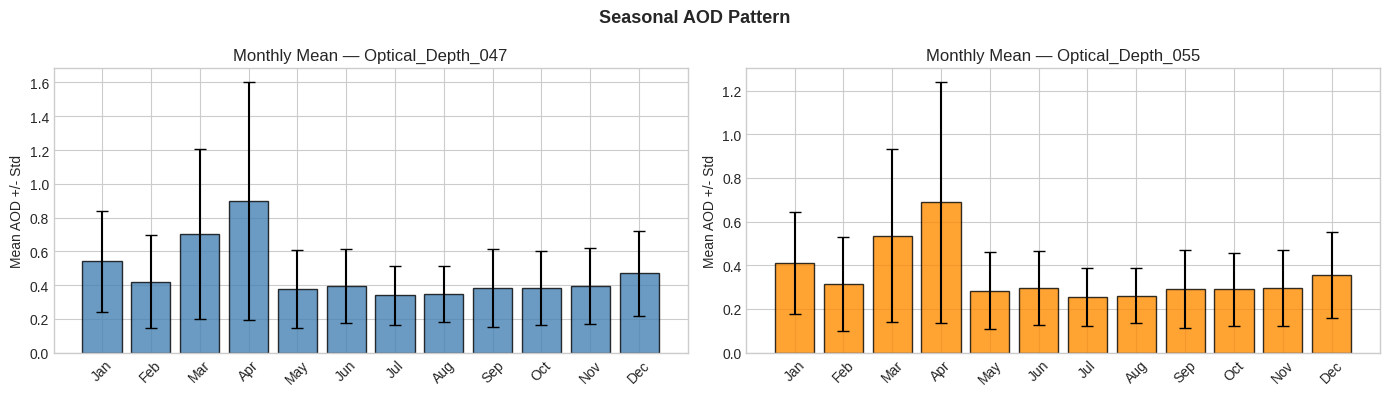

In [13]:
# Monthly mean
monthly = data.groupby('month')[AOD_COLS].agg(['mean', 'std'])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col, color in zip(axes, AOD_COLS, ['steelblue', 'darkorange']):
    means = monthly[col]['mean']
    stds  = monthly[col]['std']
    ax.bar(means.index, means, yerr=stds, color=color, edgecolor='k', capsize=4, alpha=0.8)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(MONTH_LABELS, rotation=45)
    ax.set_ylabel('Mean AOD +/- Std')
    ax.set_title(f'Monthly Mean — {col}')

plt.suptitle('Seasonal AOD Pattern', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

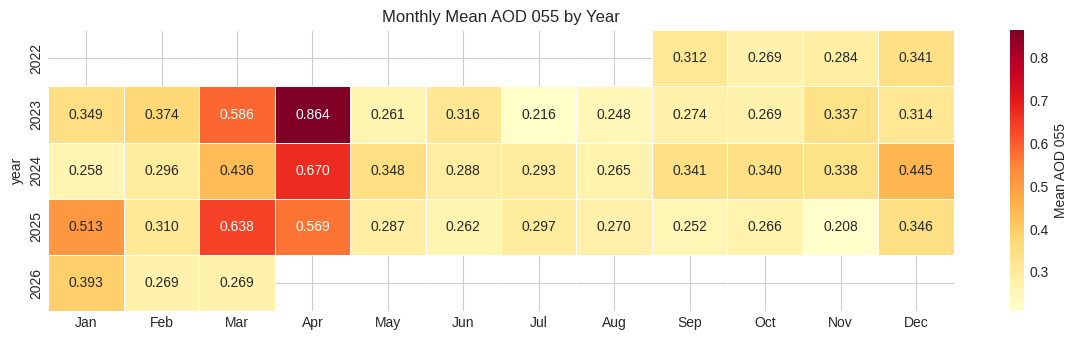

In [14]:
# Year x Month heatmap
pivot = (
    data.groupby(['year', 'month'])['Optical_Depth_055']
        .mean()
        .unstack('month')
)
pivot.columns = [MONTH_LABELS[m - 1] for m in pivot.columns]

fig, ax = plt.subplots(figsize=(12, max(3, len(pivot) * 0.7)))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd', linewidths=0.5,
            ax=ax, cbar_kws={'label': 'Mean AOD 055'})
ax.set_title('Monthly Mean AOD 055 by Year')
plt.tight_layout()
plt.show()

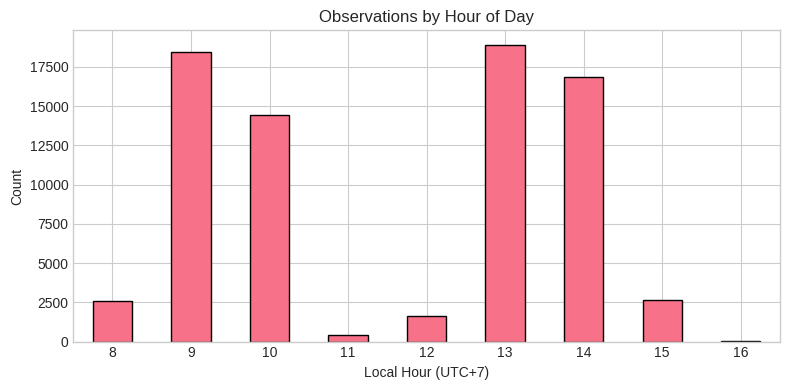

In [15]:
# Observation hour distribution
fig, ax = plt.subplots(figsize=(8, 4))
data['hour'].value_counts().sort_index().plot(kind='bar', ax=ax, edgecolor='k')
ax.set_xlabel('Local Hour (UTC+7)')
ax.set_ylabel('Count')
ax.set_title('Observations by Hour of Day')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

## 9. Per-Station Statistics

In [16]:
station_stats = (
    data.groupby('stationName')
        .agg(
            n=('Optical_Depth_055', 'count'),
            aod055_mean=('Optical_Depth_055', 'mean'),
            aod055_median=('Optical_Depth_055', 'median'),
            aod055_std=('Optical_Depth_055', 'std'),
            aod047_mean=('Optical_Depth_047', 'mean'),
        )
        .sort_values('aod055_mean', ascending=False)
        .round(4)
)
print('=== Per-station AOD statistics (sorted by mean AOD 055) ===')
print(station_stats.to_string())

=== Per-station AOD statistics (sorted by mean AOD 055) ===
                                                                                                            n  aod055_mean  aod055_median  aod055_std  aod047_mean
stationName                                                                                                                                                       
Hà Nội: Tổng cục Biển và Hải đảo, Bộ Tài nguyên và Môi trường - 83 Nguyễn Chí Thanh(LCS)                  488       0.4785         0.3915      0.3524       0.6250
Phú Thọ: đường Hùng Vương - Tp Việt Trì (KK)                                                              565       0.4756         0.3885      0.3706       0.6210
US Embassy Hanoi - 7 Láng Hạ Ba Đình                                                                      490       0.4752         0.3868      0.3475       0.6208
Hà Nội: UBND phường Định Công(LCS)                                                                        484       0.4718   

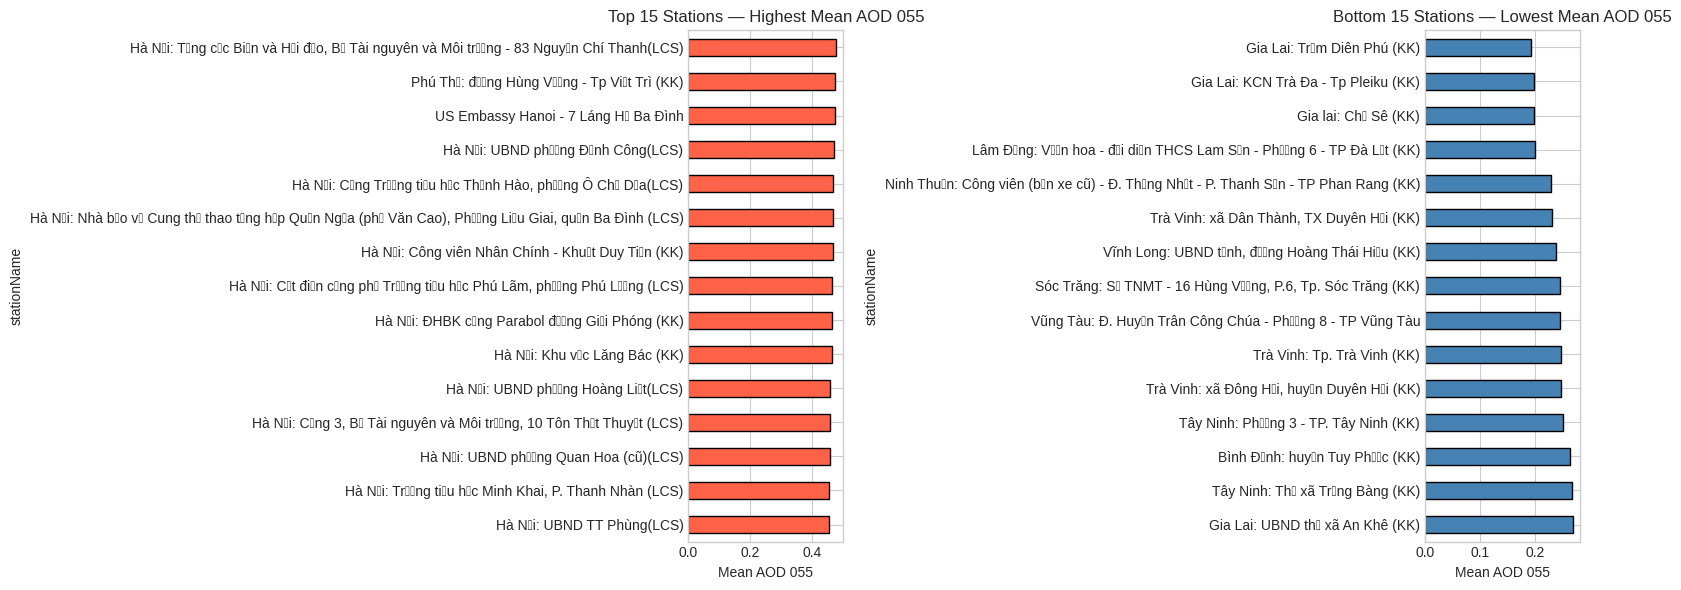

In [17]:
top15    = station_stats['aod055_mean'].head(15)
bottom15 = station_stats['aod055_mean'].tail(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
top15.sort_values().plot(kind='barh', ax=axes[0], color='tomato', edgecolor='k')
axes[0].set_xlabel('Mean AOD 055')
axes[0].set_title('Top 15 Stations — Highest Mean AOD 055')

bottom15.sort_values(ascending=False).plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='k')
axes[1].set_xlabel('Mean AOD 055')
axes[1].set_title('Bottom 15 Stations — Lowest Mean AOD 055')

plt.tight_layout()
plt.show()

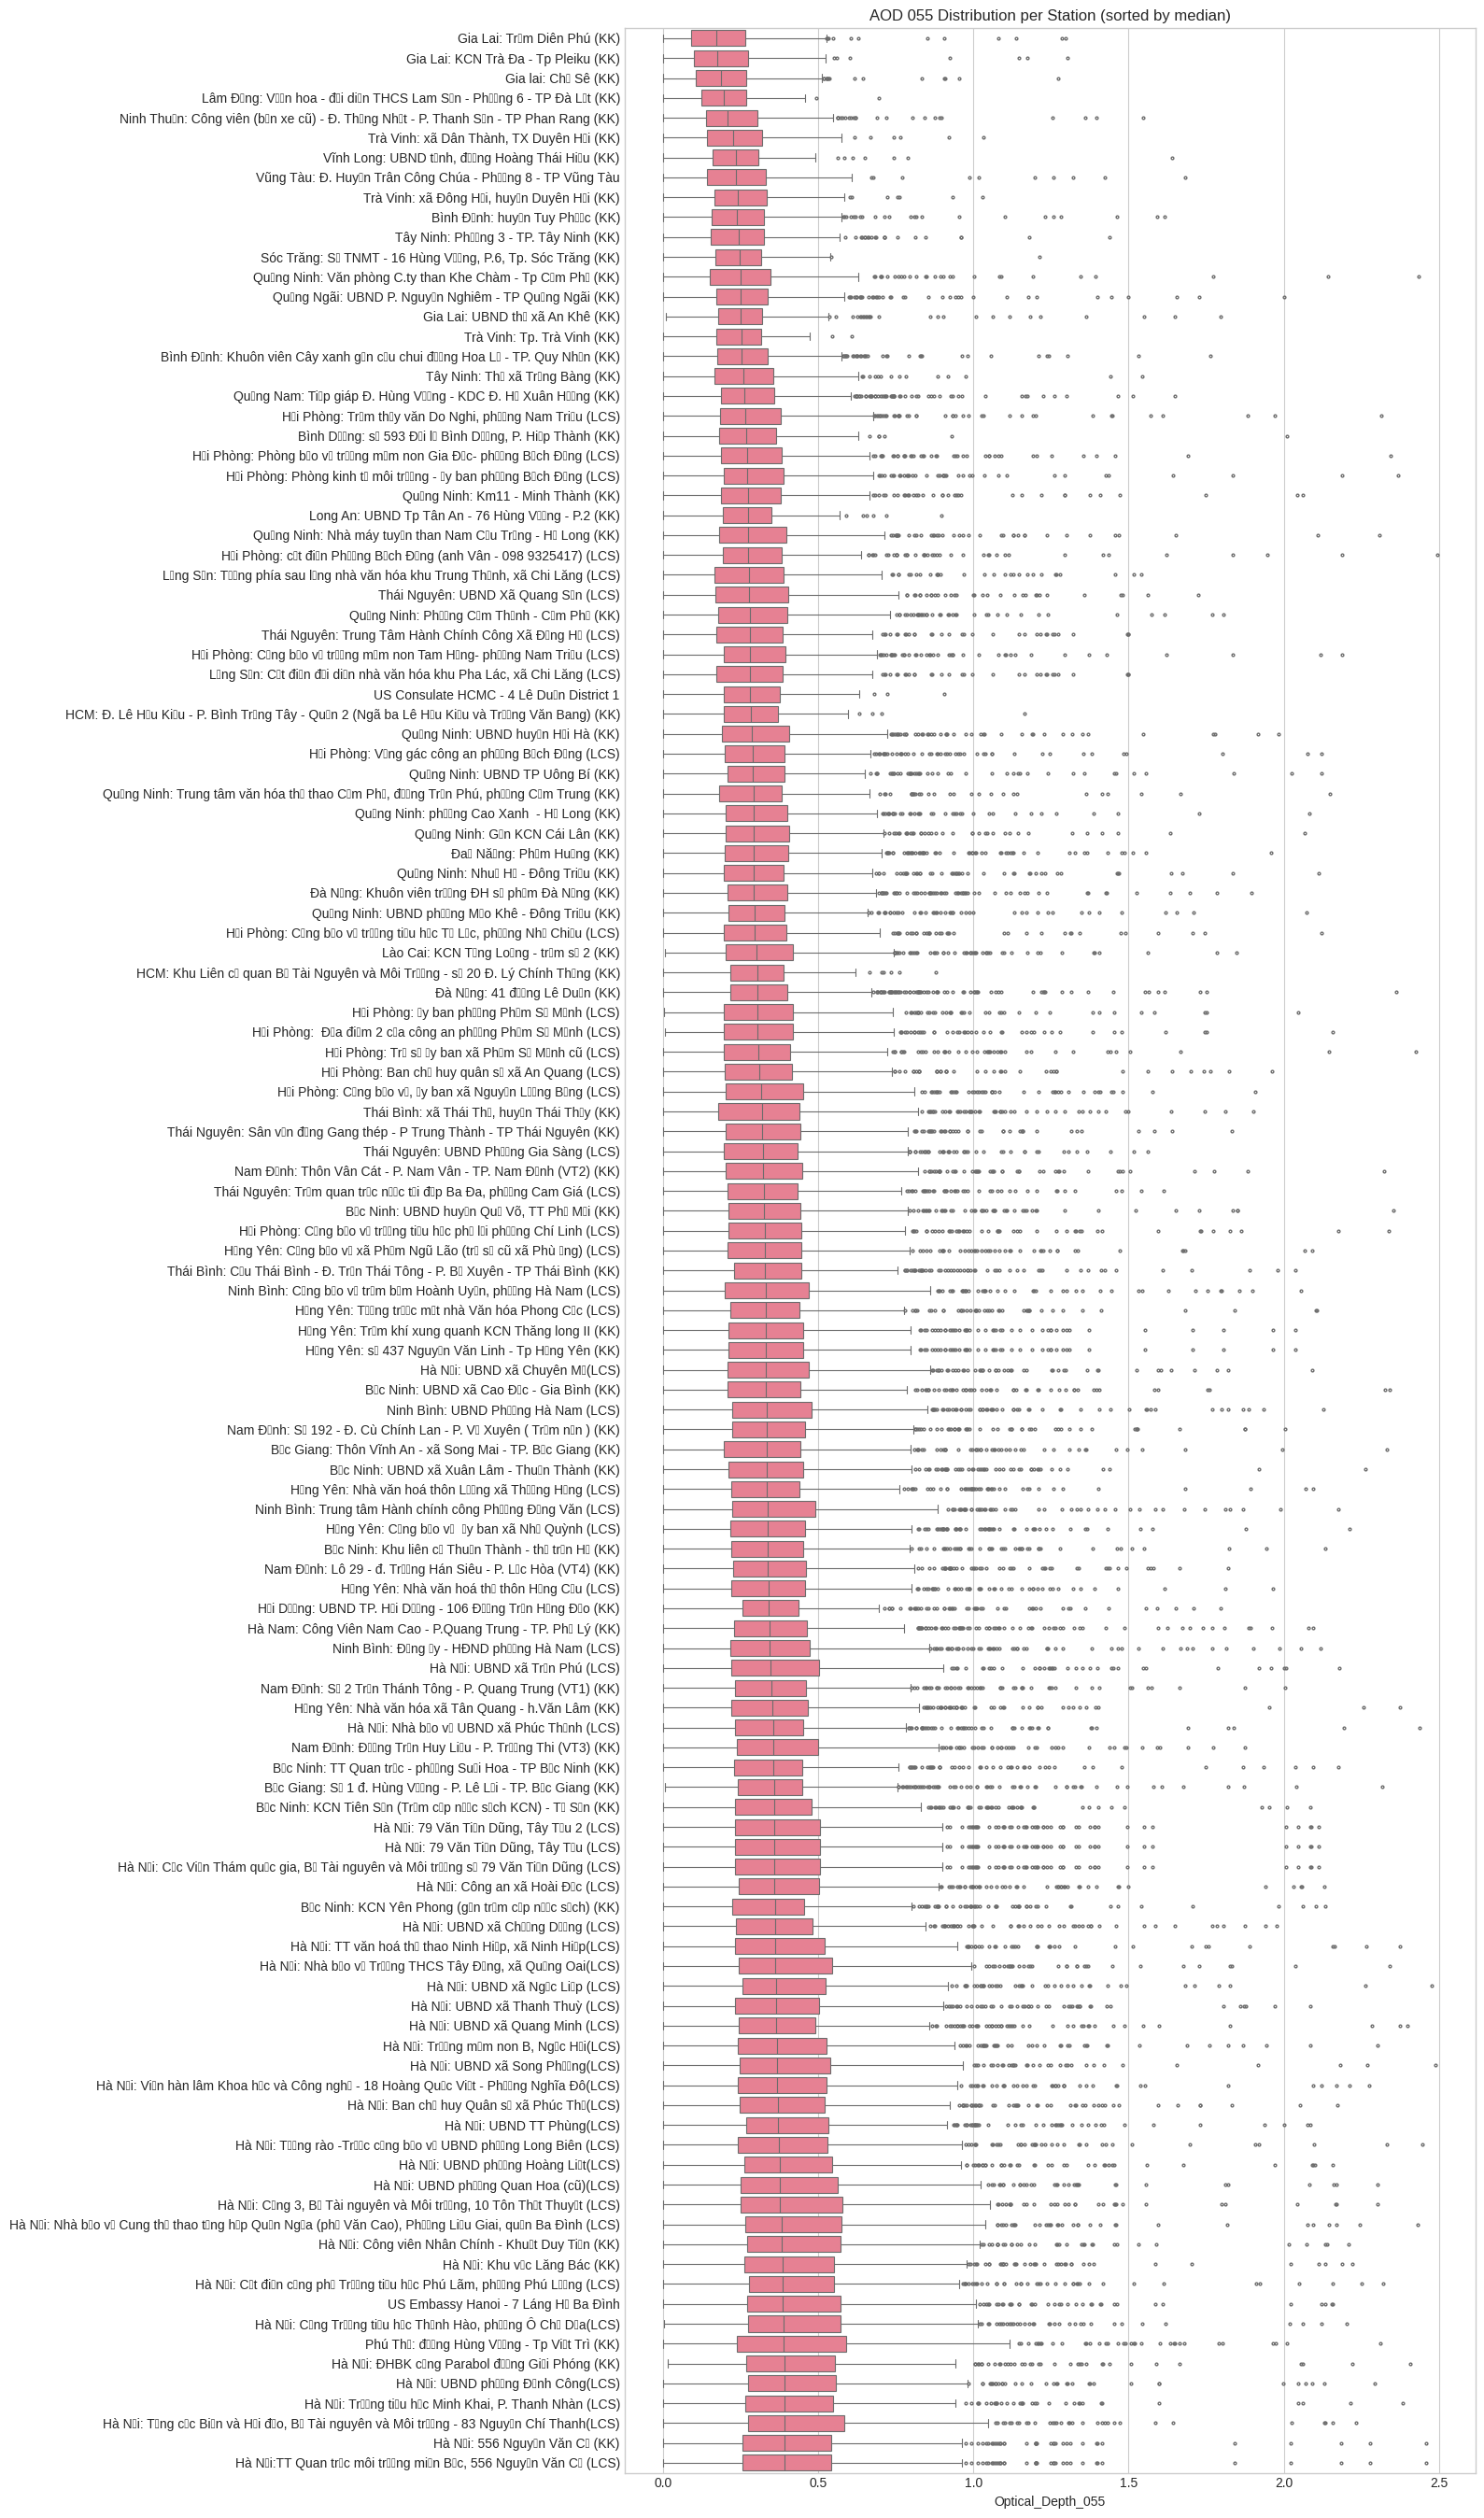

In [18]:
# Box plot per station
order = (
    data.groupby('stationName')['Optical_Depth_055']
        .median().sort_values().index
)
plot_data = data[(data['Optical_Depth_055'] >= 0) & (data['Optical_Depth_055'] <= 2.5)]

fig, ax = plt.subplots(figsize=(16, max(8, len(order) * 0.22)))
sns.boxplot(data=plot_data, y='stationName', x='Optical_Depth_055',
            order=order, ax=ax, linewidth=0.8, fliersize=2)
ax.set_xlabel('Optical_Depth_055')
ax.set_ylabel('')
ax.set_title('AOD 055 Distribution per Station (sorted by median)')
plt.tight_layout()
plt.show()

## 10. Auxiliary Variables

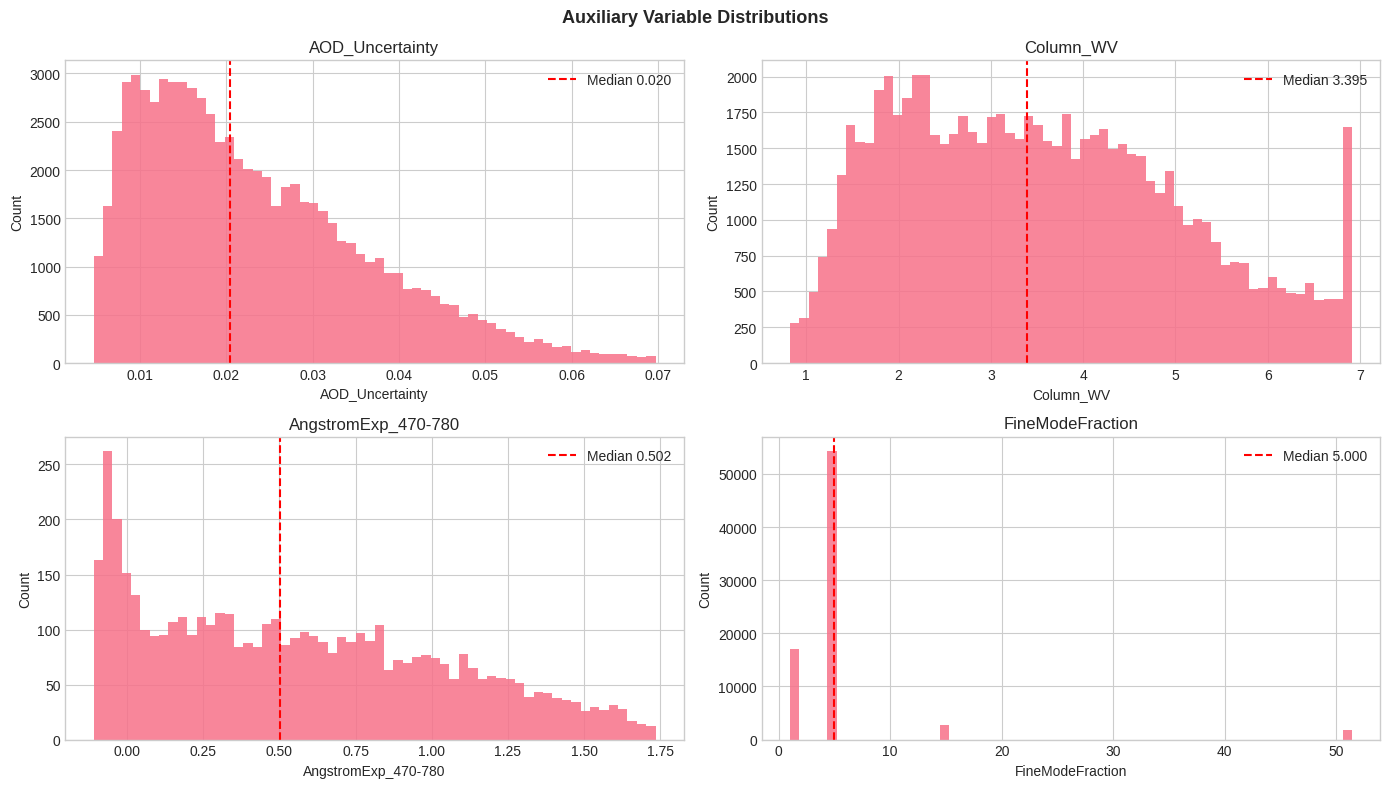

In [19]:
aux_plot = ['AOD_Uncertainty', 'Column_WV', 'AngstromExp_470-780', 'FineModeFraction']
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, col in zip(axes, aux_plot):
    vals = data[col].dropna()
    if len(vals) == 0:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(col)
        continue
    lo, hi = vals.quantile(0.01), vals.quantile(0.99)
    vals_clip = vals[(vals >= lo) & (vals <= hi)]
    ax.hist(vals_clip, bins=60, edgecolor='none', alpha=0.85)
    ax.axvline(vals_clip.median(), color='red', lw=1.5, linestyle='--',
               label=f'Median {vals_clip.median():.3f}')
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.legend()

plt.suptitle('Auxiliary Variable Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

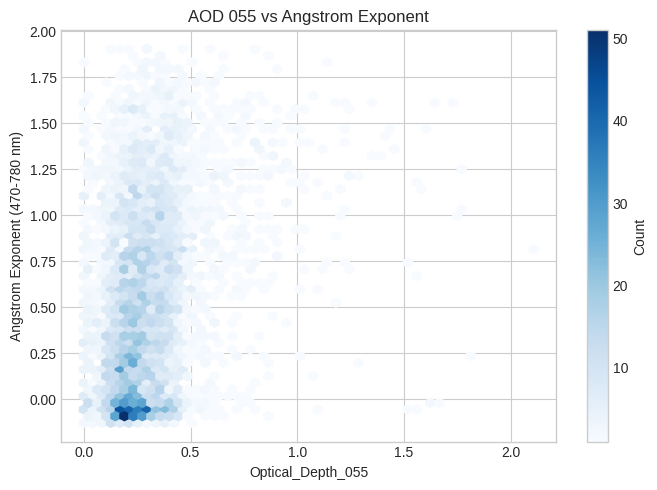

In [20]:
# Angstrom Exponent vs AOD 055
mask = data['AngstromExp_470-780'].notna() & data['Optical_Depth_055'].notna()
sample = data[mask].sample(min(20_000, mask.sum()), random_state=42)

fig, ax = plt.subplots(figsize=(7, 5))
h = ax.hexbin(sample['Optical_Depth_055'], sample['AngstromExp_470-780'],
              gridsize=50, cmap='Blues', mincnt=1)
ax.set_xlabel('Optical_Depth_055')
ax.set_ylabel('Angstrom Exponent (470-780 nm)')
ax.set_title('AOD 055 vs Angstrom Exponent')
plt.colorbar(h, ax=ax, label='Count')
plt.tight_layout()
plt.show()

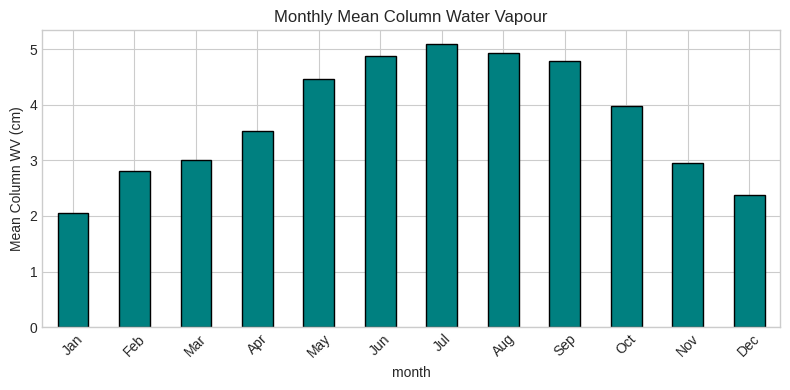

In [21]:
# Monthly Column_WV
fig, ax = plt.subplots(figsize=(8, 4))
data.groupby('month')['Column_WV'].mean().plot(kind='bar', ax=ax, color='teal', edgecolor='k')
ax.set_xticks(range(12))
ax.set_xticklabels(MONTH_LABELS, rotation=45)
ax.set_ylabel('Mean Column WV (cm)')
ax.set_title('Monthly Mean Column Water Vapour')
plt.tight_layout()
plt.show()

## 11. Correlation Matrix

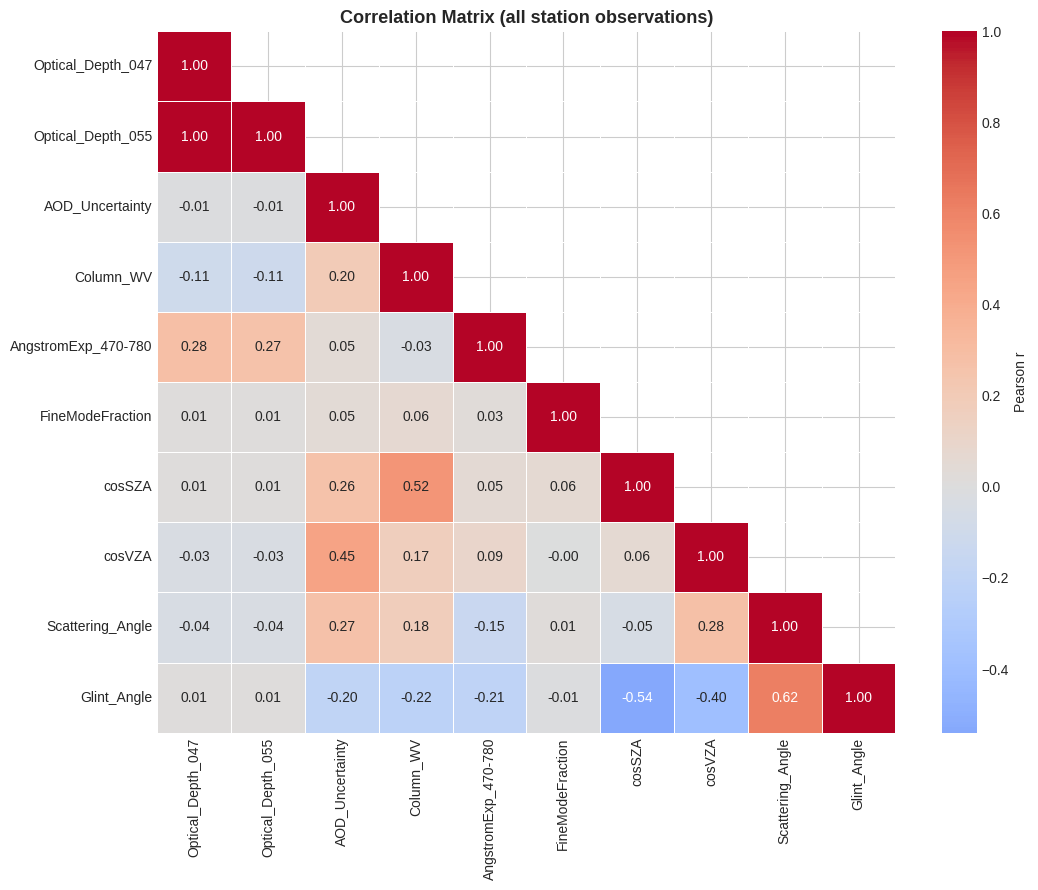

In [22]:
corr_cols = (AOD_COLS
             + ['AOD_Uncertainty', 'Column_WV', 'AngstromExp_470-780', 'FineModeFraction']
             + ['cosSZA', 'cosVZA', 'Scattering_Angle', 'Glint_Angle'])
corr_cols = [c for c in corr_cols if c in data.columns]

corr = data[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask_upper = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.4, ax=ax, mask=mask_upper,
            cbar_kws={'label': 'Pearson r'})
ax.set_title('Correlation Matrix (all station observations)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 12. Summary

In [23]:
print('=' * 60)
print('MCD19A2 STATION EDA -- SUMMARY')
print('=' * 60)
print(f'Stations      : {data["stationId"].nunique()}')
print(f'Total records : {len(data):,}')
print(f'Date range    : {data["date"].min().date()} -> {data["date"].max().date()}')
print()
for col in AOD_COLS:
    v = data[col].dropna()
    print(f'{col}: mean={v.mean():.4f}  median={v.median():.4f}  '
          f'std={v.std():.4f}  valid={len(v):,} ({len(v)/len(data)*100:.1f}%)')
print()
print(f'AOD_QA available : {data["AOD_QA"].notna().sum():,}')
fr = data['Optical_Depth_055_fill_ring']
print(f'Filled pixels (AOD 055 fill_ring > 0) : {(fr > 0).sum():,}')
print('=' * 60)

MCD19A2 STATION EDA -- SUMMARY
Stations      : 123
Total records : 75,876
Date range    : 2022-09-01 -> 2026-03-10

Optical_Depth_047: mean=0.4672  median=0.4020  std=0.3492  valid=75,876 (100.0%)
Optical_Depth_055: mean=0.3536  median=0.3000  std=0.2719  valid=75,876 (100.0%)

AOD_QA available : 75,876
Filled pixels (AOD 055 fill_ring > 0) : 36,760
